# 04 — Column Selection for Final Chapter 0 Dataset

This notebook performs a focused review of all columns produced by the Chapter 0 pipeline. The goal is to identify and remove noisy, redundant, or low-value fields before passing the dataset into Chapter 1.

### Purpose
- Reduce unnecessary dimensionality.
- Eliminate columns that are either duplicates, unused, or offer no predictive value.
- Ensure the final Chapter 0 dataset is clean, efficient, and modelling-ready.

### What this notebook does
- Loads the final pipeline output with all engineered fields.
- Examines each column for:
  - Redundancy (duplicate information or derivable fields)
  - Low variability or constant values
  - Columns used only internally during intermediate steps
  - High-cardinality identifiers not useful for modelling
- Documents which features are safe to drop.
- Updates the list of retained columns for downstream modelling.

### Outcome
A curated, simplified feature set that becomes the *locked* Chapter 0 dataset used throughout Chapter 1.  
This notebook is exploratory but directly informs the final structure of the modelling dataset.


In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [2]:
from src.job_intel.config import CH0_PROCESSED_JOBS_FILE

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(CH0_PROCESSED_JOBS_FILE)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6162 entries, 0 to 6161
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Job Title                                 6162 non-null   object 
 1   Salary Estimate                           6161 non-null   object 
 2   Job Description                           6162 non-null   object 
 3   Rating                                    5481 non-null   float64
 4   Size                                      5770 non-null   object 
 5   Founded                                   4525 non-null   float64
 6   Industry                                  5263 non-null   object 
 7   Sector                                    5263 non-null   object 
 8   role_source                               6162 non-null   object 
 9   state                                     6162 non-null   object 
 10  state_hq                            

In [5]:
df

,Job Title,Salary Estimate,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,...,cloud__advanced,db_storage__basic,db_storage__intermediate,db_storage__advanced,productivity_workflow__basic,productivity_workflow__intermediate,productivity_workflow__advanced,soft_skills__core,soft_skills__leadership,domain_specific__none
0,Senior Data Scientist,$111K-$181K (Glassdoor est.),"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007.0,Travel Agencies,Travel & Tourism,data_scientist,NY,...,0,1,0,0,0,0,0,1,0,0
1,"Data Scientist, Product Analytics",$111K-$181K (Glassdoor est.),"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008.0,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,...,0,1,0,0,0,0,0,1,0,0
2,Data Science Manager,$111K-$181K (Glassdoor est.),Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,NaN,NaN,NaN,data_scientist,NY,...,0,0,0,0,0,0,0,1,1,1
3,Data Analyst,$111K-$181K (Glassdoor est.),Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019.0,Internet,Information Technology,data_scientist,NJ,...,0,1,0,0,0,0,0,1,1,0
4,"Director, Data Science",$111K-$181K (Glassdoor est.),"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007.0,Advertising & Marketing,Business Services,data_scientist,NY,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6157,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,51 to 200 employees,NaN,Staffing & Outsourcing,Business Services,data_analyst,CO,...,0,0,0,0,0,0,0,0,0,0
6158,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,10000+ employees,1935.0,Wholesale,Business Services,data_analyst,CO,...,0,1,1,0,0,0,0,1,1,0
6159,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",NaN,NaN,NaN,NaN,NaN,data_analyst,CO,...,0,1,0,0,1,0,0,1,1,1
6160,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,201 to 500 employees,1984.0,Enterprise Software & Network Solutions,Information Technology,data_analyst,CO,...,0,1,1,0,0,0,0,1,1,0


In [1]:
keep = [
    # General description
    'Rating', 'Size', 'Founded', 
    'Industry', 'Sector', 'state', 
    'ownership_clean', 
    # Seniority
    'seniority_combined',
    # Title
    'job_title_family', 'domain',
    # Salary
    'sal_min', 'sal_max', 'sal_mean',
    # Skills
    'core_programming__basic', 'core_programming__intermediate',
    'core_programming__advanced', 'data_engineering_pipelines__basic',
    'data_engineering_pipelines__intermediate',
    'data_engineering_pipelines__advanced', 'ml_ai__basic',
    'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
    'analytics_stats__intermediate', 'analytics_stats__advanced',
    'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
    'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
    'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
    'productivity_workflow__basic', 'productivity_workflow__intermediate',
    'productivity_workflow__advanced', 'soft_skills__core',
    'soft_skills__leadership', 'domain_specific__none',
    # Checks
    'title_plus_description', # check skill extraction
    'Job Description', # Check complete job description
    'job_title_base', # Check cleaned title
    'job_title_norm', # Because ChatGTP says so
    'role_source', # Allows checking to which dataset each add belong to
    'job_description_clean', # For future skill extraction
    'sal_is_hourly', 
]

drop = [
    'Job Title', # Only need the clean title to check for family and domain.
    'job_title_for_skills', # This in already incorporated in the title_plus_description if we want to check for skills
    'job_title_raw', # This is purely an intermediate column that passes a superfitial cleaning from the original Job Title - useless for checking. Literally just the strip to which we apply the cleaning function
    'Salary Estimate', # Trust the code no need to have raw data
    'seniority_roman', # Partial extraction from just roman numbers - incomplete. Using the combined seniority instead
    'seniority_title', # Partial extraction from just title - incomplete. Using the combined seniority instead
    'seniority_description', # Partial extraction from just description - incomplete. Using the combined seniority instead
    'state_hq', # Noisy. Let's just keep the location of the actual role, not the headquarters of the company
]

In [2]:
len(keep)

47

In [7]:
len(keep + drop) == len(df.columns)

True

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

seniority_roman                             94.985394
Founded                                     26.566050
Industry                                    14.589419
Sector                                      14.589419
Rating                                      11.051607
state_hq                                     6.686141
Size                                         6.361571
Salary Estimate                              0.016228
sal_min                                      0.016228
sal_max                                      0.016228
sal_mean                                     0.016228
job_description_clean                        0.016228
bi_viz__basic                                0.000000
Job Title                                    0.000000
analytics_stats__advanced                    0.000000
bi_viz__advanced                             0.000000
analytics_stats__intermediate                0.000000
analytics_stats__basic                       0.000000
ml_ai__advanced             

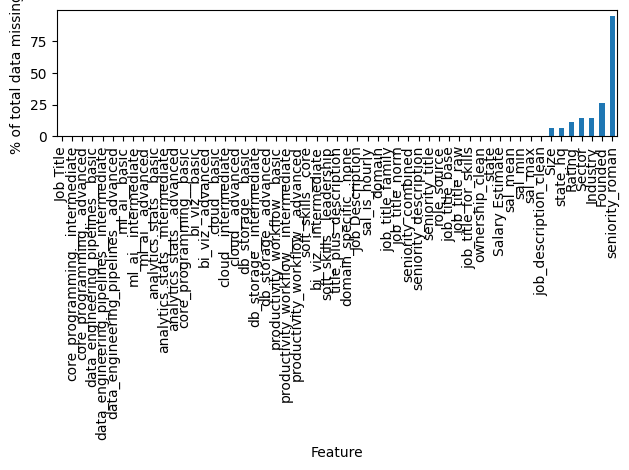

In [9]:
df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values().plot(kind = 'bar')
plt.ylabel('% of total data missing')
plt.xlabel('Feature')
plt.tight_layout()

df.isna().apply(lambda x: (sum(x) / (len(df)))*100).sort_values(ascending=False)